<a href="https://colab.research.google.com/github/rofiat13/projects/blob/main/Exploratory_data_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
task=pd.read_csv('pharma_data.csv')
task.head()
#task.shape

,Unnamed: 0,ID_Patient_Care_Situation,Diagnosed_Condition,Patient_ID,Treated_with_drugs,Patient_Age,Patient_Body_Mass_Index,Patient_Smoker,Patient_Rural_Urban,Patient_mental_condition,A,B,C,D,E,F,Z,Number_of_prev_cond,Survived_1_year
0,0,22374,8,3333,DX6,56,18.479385,YES,URBAN,Stable,1.0,0.0,0.0,0.0,1.0,0.0,0.0,2.0,0
1,1,18164,5,5740,DX2,36,22.945566,YES,RURAL,Stable,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1
2,2,6283,23,10446,DX6,48,27.510027,YES,RURAL,Stable,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0
3,3,5339,51,12011,DX1,5,19.130976,NO,URBAN,Stable,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1
4,4,33012,0,12513,NaN,128,1.348400,Cannot say,RURAL,Stable,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1


In [ ]:
del task['Unnamed: 0']

In [ ]:
task.head()

,ID_Patient_Care_Situation,Diagnosed_Condition,Patient_ID,Treated_with_drugs,Patient_Age,Patient_Body_Mass_Index,Patient_Smoker,Patient_Rural_Urban,Patient_mental_condition,A,B,C,D,E,F,Z,Number_of_prev_cond,Survived_1_year
0,22374,8,3333,DX6,56,18.479385,YES,URBAN,Stable,1.0,0.0,0.0,0.0,1.0,0.0,0.0,2.0,0
1,18164,5,5740,DX2,36,22.945566,YES,RURAL,Stable,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1
2,6283,23,10446,DX6,48,27.510027,YES,RURAL,Stable,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0
3,5339,51,12011,DX1,5,19.130976,NO,URBAN,Stable,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1
4,33012,0,12513,NaN,128,1.348400,Cannot say,RURAL,Stable,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1


In [ ]:
task.shape
#there are 23097 rows and 18 columns

(23097, 18)

In [ ]:
task.info()
#there are 9 columns with complete data, that is, ID_patient_care_situation, Diagnosed_condition, Patient_ID, Patient_Age, Patient_Body_Mass_Index, Patient_Smoker, Patient_Rural_Urban, Patient_mental_condition, Survived_1_year.     
#there are 9 columns with incomplete data. the columns are A,B,C,D,E,F,Z and Number_of_prev_cond have 1235 missing data and Treated_with_drugs with 13 missing data

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23097 entries, 0 to 23096
Data columns (total 18 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   ID_Patient_Care_Situation  23097 non-null  int64  
 1   Diagnosed_Condition        23097 non-null  int64  
 2   Patient_ID                 23097 non-null  int64  
 3   Treated_with_drugs         23084 non-null  object 
 4   Patient_Age                23097 non-null  int64  
 5   Patient_Body_Mass_Index    23097 non-null  float64
 6   Patient_Smoker             23097 non-null  object 
 7   Patient_Rural_Urban        23097 non-null  object 
 8   Patient_mental_condition   23097 non-null  object 
 9   A                          21862 non-null  float64
 10  B                          21862 non-null  float64
 11  C                          21862 non-null  float64
 12  D                          21862 non-null  float64
 13  E                          21862 non-null  flo

In [ ]:
task.isnull().sum()

ID_Patient_Care_Situation       0
Diagnosed_Condition             0
Patient_ID                      0
Treated_with_drugs             13
Patient_Age                     0
Patient_Body_Mass_Index         0
Patient_Smoker                  0
Patient_Rural_Urban             0
Patient_mental_condition        0
A                            1235
B                            1235
C                            1235
D                            1235
E                            1235
F                            1235
Z                            1235
Number_of_prev_cond          1235
Survived_1_year                 0
dtype: int64

In [ ]:
task.describe()

,ID_Patient_Care_Situation,Diagnosed_Condition,Patient_ID,Patient_Age,Patient_Body_Mass_Index,A,B,C,D,E,F,Z,Number_of_prev_cond,Survived_1_year
count,23097.000000,23097.000000,23097.000000,23097.000000,23097.000000,21862.000000,21862.000000,21862.000000,21862.000000,21862.000000,21862.000000,21862.000000,21862.000000,23097.000000
mean,16545.712041,26.413127,6261.280772,33.209768,23.454820,0.897905,0.136355,0.185070,0.083615,0.393239,0.053700,0.000595,1.750480,0.632247
std,9532.263503,15.030865,3595.990620,19.549882,3.807661,0.302780,0.343173,0.388363,0.276817,0.488480,0.225431,0.024379,0.770311,0.482204
min,2.000000,0.000000,1.000000,0.000000,1.089300,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
25%,8280.000000,13.000000,3181.000000,16.000000,20.205550,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
50%,16597.000000,26.000000,6242.000000,33.000000,23.386199,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,1.000000
75%,24825.000000,39.000000,9363.000000,50.000000,26.788154,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,2.000000,1.000000
max,33014.000000,52.000000,12515.000000,149.000000,29.999579,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,5.000000,1.000000


In [ ]:
#patient age

{'boxes': [<matplotlib.lines.Line2D at 0x7f02097425f8>],
 'caps': [<matplotlib.lines.Line2D at 0x7f0209742fd0>,
 'fliers': [<matplotlib.lines.Line2D at 0x7f02096daa90>],
 'means': [],
 'medians': [<matplotlib.lines.Line2D at 0x7f02096da710>],
 'whiskers': [<matplotlib.lines.Line2D at 0x7f0209fa6828>,
  <matplotlib.lines.Line2D at 0x7f0209742c50>]}

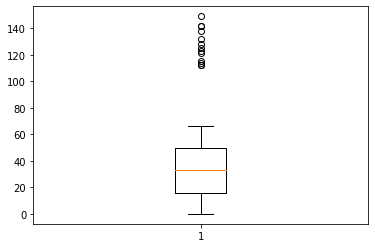

In [ ]:
plt.boxplot(task['Patient_Age'])

/usr/local/lib/python3.6/dist-packages/matplotlib/cbook/__init__.py:1239: RuntimeWarning: invalid value encountered in less_equal
  wiskhi = x[x <= hival]
/usr/local/lib/python3.6/dist-packages/matplotlib/cbook/__init__.py:1246: RuntimeWarning: invalid value encountered in greater_equal
  wisklo = x[x >= loval]
/usr/local/lib/python3.6/dist-packages/matplotlib/cbook/__init__.py:1254: RuntimeWarning: invalid value encountered in less
  x[x < stats['whislo']],
/usr/local/lib/python3.6/dist-packages/matplotlib/cbook/__init__.py:1255: RuntimeWarning: invalid value encountered in greater
  x[x > stats['whishi']],


{'boxes': [<matplotlib.lines.Line2D at 0x7f020921e0f0>,
 'caps': [<matplotlib.lines.Line2D at 0x7f020921ebe0>,
 'fliers': [<matplotlib.lines.Line2D at 0x7f02091cf6a0>,
 'means': [],
 'medians': [<matplotlib.lines.Line2D at 0x7f02091cf320>,
 'whiskers': [<matplotlib.lines.Line2D at 0x7f020921e518>,
  <matplotlib.lines.Line2D at 0x7f020911fbe0>]}

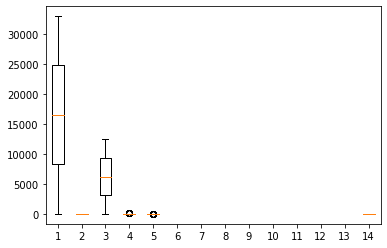

In [ ]:
data=[task['ID_Patient_Care_Situation'], task['Diagnosed_Condition'], task['Patient_ID'], task['Patient_Age'],task['Patient_Body_Mass_Index'], task['A'], task['B'], task['C'], task['D'], task['E'], task['F'], task['Z'], task['Number_of_prev_cond'], task['Survived_1_year']]
plt.boxplot(data)

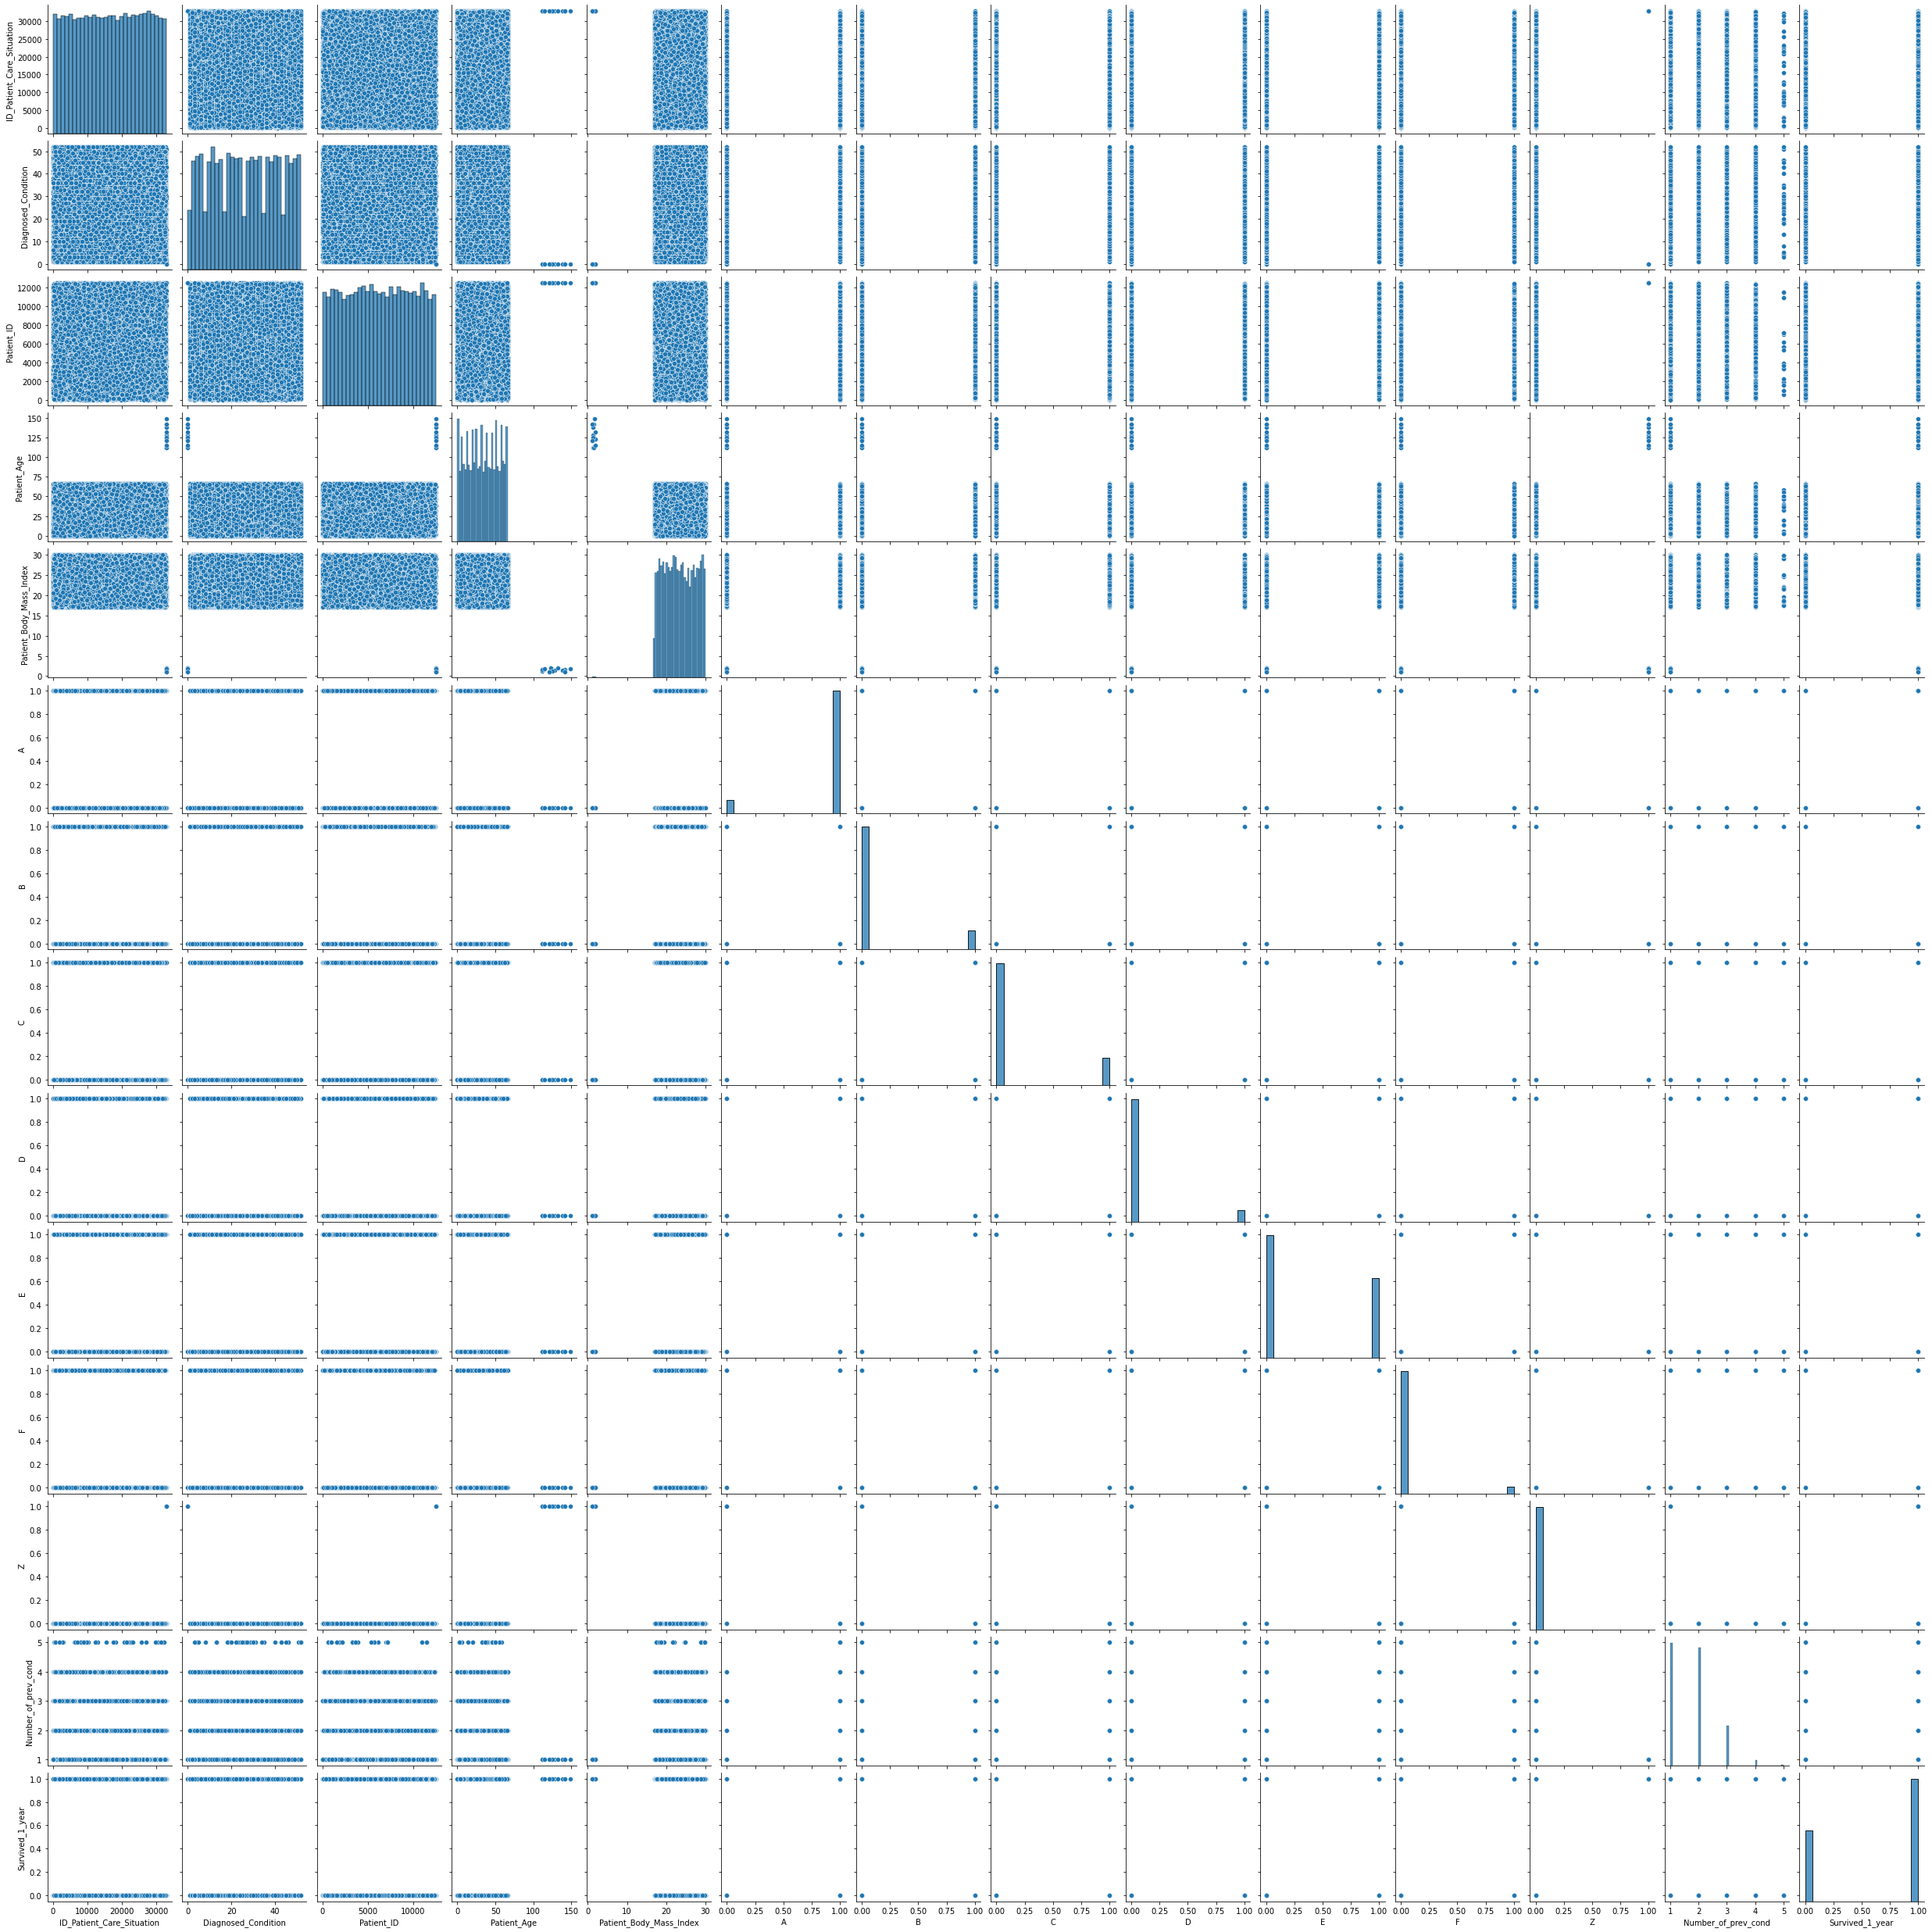

In [ ]:
sns.pairplot(task)

In [ ]:
task.columns

Index(['ID_Patient_Care_Situation', 'Diagnosed_Condition', 'Patient_ID',
       'Treated_with_drugs', 'Patient_Age', 'Patient_Body_Mass_Index',
       'Patient_Smoker', 'Patient_Rural_Urban', 'Patient_mental_condition',
       'A', 'B', 'C', 'D', 'E', 'F', 'Z', 'Number_of_prev_cond',
       'Survived_1_year'],
      dtype='object')

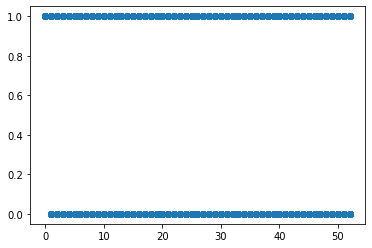

In [ ]:
plt.scatter(task['Diagnosed_Condition'],task['Survived_1_year'])

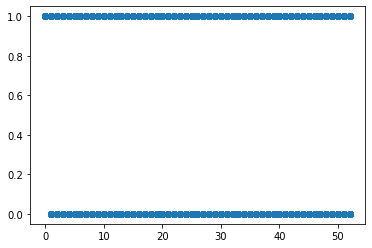

In [ ]:
plt.scatter(task['Diagnosed_Condition'],task['Survived_1_year'])

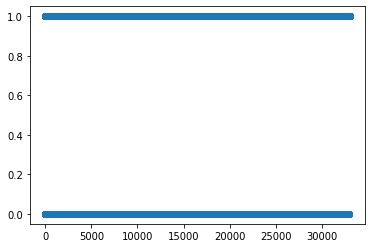

In [ ]:
plt.scatter(task['ID_Patient_Care_Situation'],task['Survived_1_year'])

In [ ]:
plt.scatter(task['Treated_with_drugs'],task['Survived_1_year'])

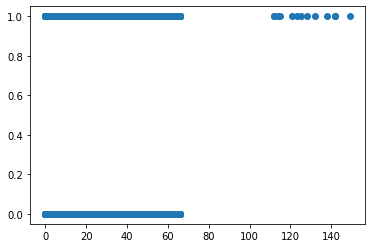

In [ ]:
plt.scatter(task['Patient_Age'],task['Survived_1_year'])

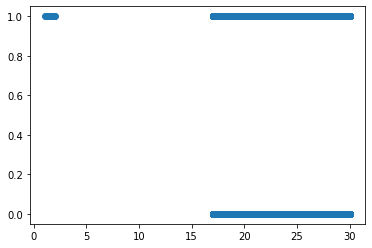

In [ ]:
plt.scatter(task['Patient_Body_Mass_Index'],task['Survived_1_year'])

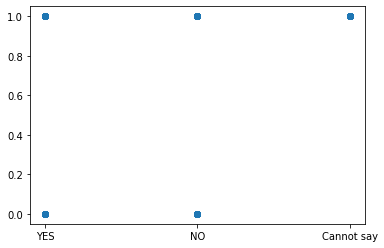

In [ ]:
plt.scatter(task['Patient_Smoker'],task['Survived_1_year'])

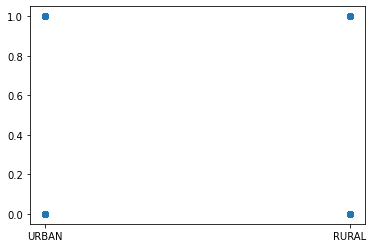

In [ ]:
plt.scatter(task['Patient_Rural_Urban'],task['Survived_1_year'])

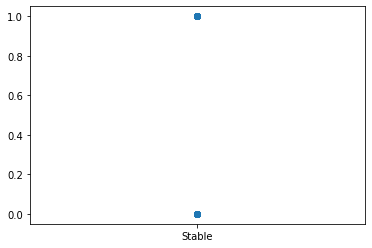

In [ ]:
plt.scatter(task['Patient_mental_condition'],task['Survived_1_year'])

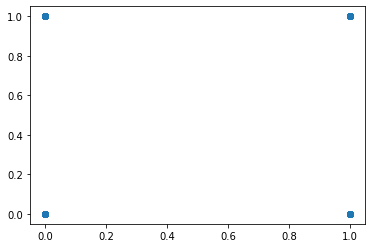

In [ ]:
plt.scatter(task['A'],task['Survived_1_year'])

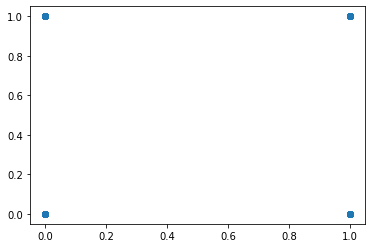

In [ ]:
plt.scatter(task['B'],task['Survived_1_year'])

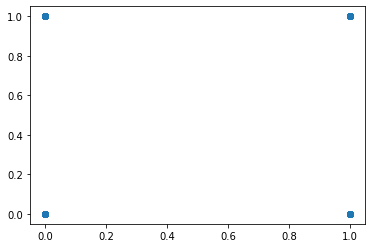

In [ ]:
plt.scatter(task['C'],task['Survived_1_year'])

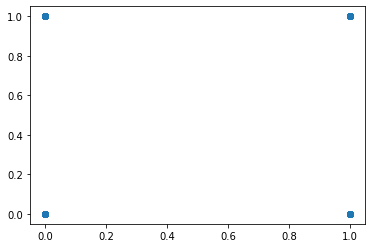

In [ ]:
plt.scatter(task['D'],task['Survived_1_year'])

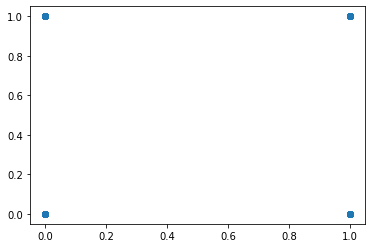

In [ ]:
plt.scatter(task['E'],task['Survived_1_year'])

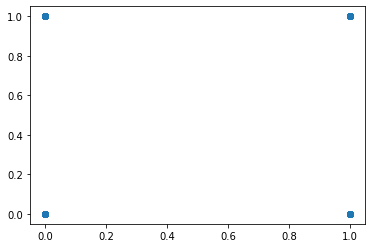

In [ ]:
plt.scatter(task['F'],task['Survived_1_year'])

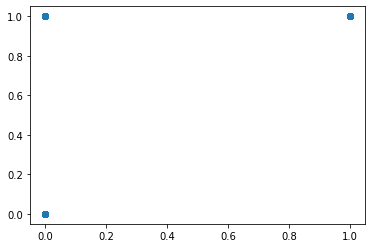

In [ ]:
plt.scatter(task['Z'],task['Survived_1_year'])

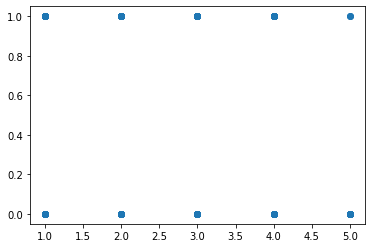

In [ ]:
plt.scatter(task['Number_of_prev_cond'],task['Survived_1_year'])

In [ ]:
#task['Number_of_prev_cond']= np.log(1+ task['Number_of_prev_cond'])

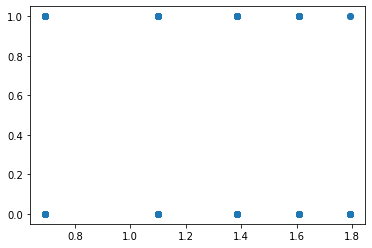

In [ ]:
#plt.scatter(task['Number_of_prev_cond'],task['Survived_1_year'])

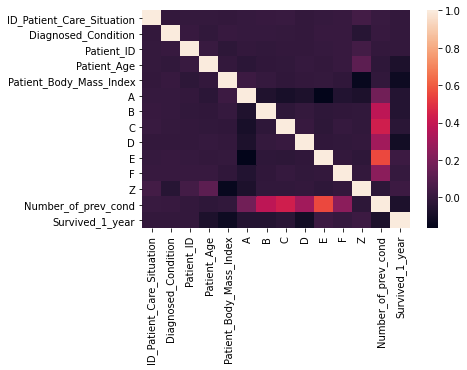

In [ ]:
corr=task.corr()
sns.heatmap(corr)

In [ ]:
plt.figure(figsize=(12,6))
plt.subplot(121)
